In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os
import torch
import torch.nn.functional as F
from tqdm import tqdm

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.data import *

!pip install networkx
import networkx as nx

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader
# from ibllib.atlas import AllenAtlas
# from brainbox.io.spikeglx import Streamer
# from neurodsp.voltage import destripe
# from datetime import datetime
# from pprint import pprint

# ba = AllenAtlas()
# br = ba.regions
# ba.compute_regions_volume()


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [4]:
from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:00<00:00, 178.85it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:00<00:00, 69.02it/s]


In [5]:
dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [ ]:
voxels = ba.label.shape

In [ ]:
voxels_res = 2
acronym_selec = []
voxels_selec = []
coordinates = []
for x in tqdm(range(0, voxels[0], voxels_res)):
    for y in range(0, voxels[1], voxels_res):
        for z in range(0, voxels[2], voxels_res):
            try:
                acronym = br.id2acronym(ba.get_labels(ba.bc.i2xyz([x, y, z]), mapping='Allen'))[0]
                if acronym not in ['void']:
                    acronym_selec.append(br.id2acronym(ba.get_labels(ba.bc.i2xyz([x, y, z]), mapping='Allen'))[0])
                    voxels_selec.append([x, y, z])
                    coordinates.append(ba.bc.i2xyz([x, y, z]))

            except:
                pass

            # pass

100%|██████████| 264/264 [2:34:41<00:00, 35.16s/it]


In [ ]:
dis_dict = {'acronym': np.array(acronym_selec), 'voxels':np.array(voxels_selec), 'coordinates':np.array(coordinates),}
torch.save(dis_dict, '/content/drive/MyDrive/Project/BrainRegionId/Science/results/dist/dis_dict.pt')
from google.colab import runtime
runtime.unassign()

In [ ]:
acronym_selec = np.array(acronym_selec)

In [ ]:
coordinates = np.array(coordinates)

In [ ]:
np.shape(coordinates)

(229709, 3)

In [ ]:
np.isnan(coordinates[np.argwhere(acronym_selec == acronym).flatten(), :].mean(axis=0))

array([False, False, False])

In [6]:
dis_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Science/results/dist/dis_dict.pt', weights_only=False)

In [7]:
coordinates = dis_dict["coordinates"]
acronym_selec = dis_dict["acronym"]

In [8]:
pos_list = []
for acronym in acronym_list:
    if True in np.isnan(coordinates[np.argwhere(acronym_selec == acronym).flatten(), :].mean(axis=0)):
        pos_list.append(pos_list[-1])
    else:
        pos_list.append(coordinates[np.argwhere(acronym_selec == acronym).flatten(), :].mean(axis=0))

distance_mat = torch.zeros(len(acronym_list), len(acronym_list))
for ii, _ in enumerate(acronym_list):
    for jj, _ in enumerate(acronym_list):
        distance_mat[ii, jj] = F.pairwise_distance(torch.tensor(pos_list[ii]), torch.tensor(pos_list[jj]))


/tmp/ipython-input-2555000536.py:3: RuntimeWarning: Mean of empty slice.
  if True in np.isnan(coordinates[np.argwhere(acronym_selec == acronym).flatten(), :].mean(axis=0)):
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [9]:
reverse_distance_mat = (distance_mat.max() - distance_mat) / (distance_mat.max() - distance_mat.min())

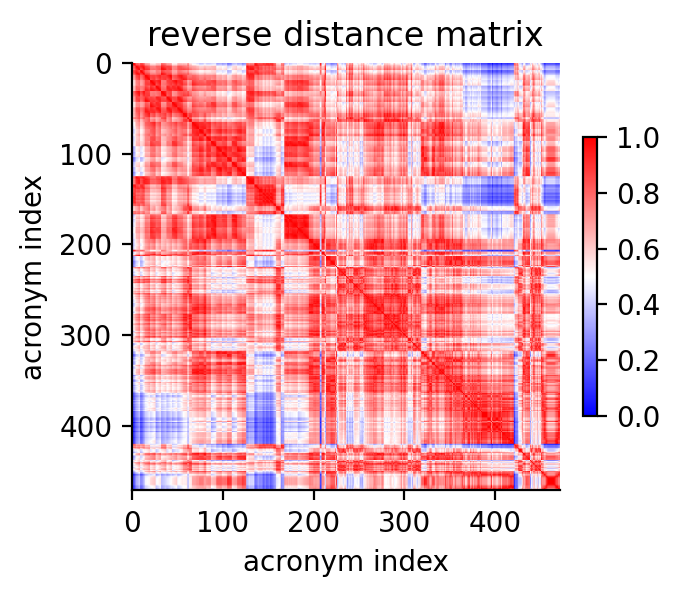

In [ ]:
plt.figure(figsize=(3, 3), dpi=200)
plt.imshow(reverse_distance_mat.detach().cpu().numpy(), cmap='bwr')
plt.xlabel('acronym index')
plt.ylabel('acronym index')
sns.despine()
plt.colorbar(fraction=0.03)
plt.title('reverse distance matrix')
plt.show()

In [14]:
modularity_value = []
for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
    G = nx.from_numpy_array(reverse_distance_mat.detach().cpu().numpy().copy())
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    label_acronym = []
    community_label = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            label_acronym.append(acronym_list[c_index])

    community_label = np.array(community_label)
    print(f'resolution: {resolution}>>>>>>>>>>>', nx.community.modularity(G, c))
    # community_label
    modularity_value.append(nx.community.modularity(G, c))
modularity_value_rd = np.array(modularity_value)



resolution: 0.2>>>>>>>>>>> 0.0
resolution: 0.4>>>>>>>>>>> 0.0
resolution: 0.6>>>>>>>>>>> 0.0
resolution: 0.8>>>>>>>>>>> 0.0
resolution: 1.0>>>>>>>>>>> 0.06768041704495092
resolution: 1.2>>>>>>>>>>> 0.0524873267511363
resolution: 1.4>>>>>>>>>>> 0.03148923018024571
resolution: 1.6>>>>>>>>>>> 0.018862212681333097
resolution: 1.8>>>>>>>>>>> 0.011899704982292786
resolution: 2.0>>>>>>>>>>> 0.008027480290407386


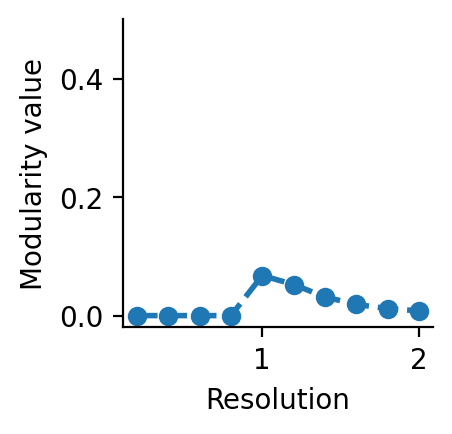

In [ ]:
plt.figure(figsize=(2, 2), dpi=200)
plt.plot([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_value, 'o--', linewidth=2)
plt.ylabel('Modularity value')
plt.xlabel('Resolution')
plt.ylim([-0.02, 0.5])
# plt.legend()
sns.despine()
plt.show()

In [15]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [16]:
Mat_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/Confusion_mat.pt', weights_only=False)

modularity_value_dict = {}
for name in [ 'AnyNet', 'ViT', 'RNN']:
    modularity_value = []
    for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
        G = nx.from_numpy_array(Mat_dict[name].copy())
        c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
        label_acronym = []
        community_label = []
        for c_ii, c0 in enumerate(c):
            for c_index in c0:
                community_label.append(c_ii)
                label_acronym.append(acronym_list[c_index])

        community_label = np.array(community_label)
        print(f'resolution: {resolution}>>>>>>>>>>>', nx.community.modularity(G, c))
        # community_label
        modularity_value.append(nx.community.modularity(G, c))
    modularity_value = np.array(modularity_value)
    modularity_value_dict[name] = modularity_value

resolution: 0.2>>>>>>>>>>> 0.04350889680845049
resolution: 0.4>>>>>>>>>>> 0.35574108457424736
resolution: 0.6>>>>>>>>>>> 0.516586673595706
resolution: 0.8>>>>>>>>>>> 0.5397727026079719
resolution: 1.0>>>>>>>>>>> 0.5490413709541084
resolution: 1.2>>>>>>>>>>> 0.5477914283167887
resolution: 1.4>>>>>>>>>>> 0.5413834677373004
resolution: 1.6>>>>>>>>>>> 0.5344992343137613
resolution: 1.8>>>>>>>>>>> 0.5330511781722492
resolution: 2.0>>>>>>>>>>> 0.5287439691246755
resolution: 0.2>>>>>>>>>>> 0.04362794917654919
resolution: 0.4>>>>>>>>>>> 0.344772535088055
resolution: 0.6>>>>>>>>>>> 0.5127628310027096
resolution: 0.8>>>>>>>>>>> 0.5440619193035316
resolution: 1.0>>>>>>>>>>> 0.5546289671593724
resolution: 1.2>>>>>>>>>>> 0.5538384500861767
resolution: 1.4>>>>>>>>>>> 0.5483040755066051
resolution: 1.6>>>>>>>>>>> 0.5438113896918944
resolution: 1.8>>>>>>>>>>> 0.5371216872164304
resolution: 2.0>>>>>>>>>>> 0.5350323043931038
resolution: 0.2>>>>>>>>>>> 0.02106606396664527
resolution: 0.4>>>>>>>>>>> 0.152

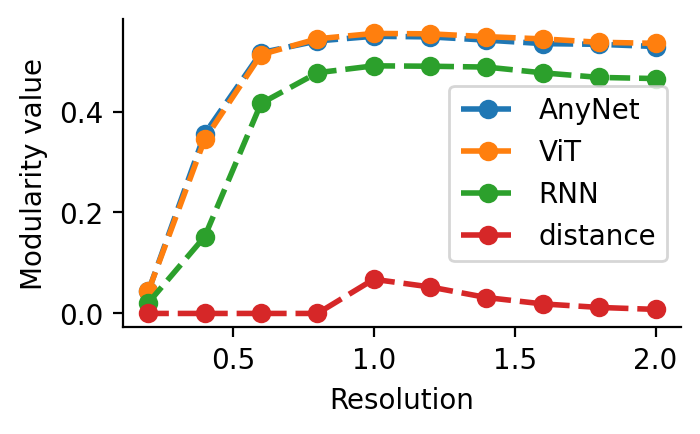

In [22]:
plt.figure(figsize=(1.8 * 2, 1 * 2), dpi=200)
for name in [ 'AnyNet', 'ViT', 'RNN']:
    plt.plot([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_value_dict[name], 'o--', linewidth=2, label=name)

plt.plot([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_value_rd, 'o--', linewidth=2, label='distance')
plt.ylabel('Modularity value')
plt.xlabel('Resolution')
plt.legend()
sns.despine()
plt.show()

In [23]:

modularity_bootstrap = []
for num in range(0, 5):
    node_ii = np.sort(np.random.choice(len(acronym_list), len(acronym_list)//5, replace=False))
    X1 = np.delete(copy.deepcopy(reverse_distance_mat.detach().cpu().numpy()), node_ii, axis=0)
    X1 = np.delete(X1, node_ii, axis=1)
    modularity_resolutions = []
    for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
        G = nx.from_numpy_array(X1.copy())
        c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
        modularity_resolutions.append(nx.community.modularity(G, c))

    modularity_resolutions = np.array(modularity_resolutions)

    modularity_bootstrap.append(modularity_resolutions)

modularity_bootstrap = np.array(modularity_bootstrap)



In [ ]:
modularity_bootstrap

array([[0.        , 0.        , 0.        , 0.        , 0.06435768,
        0.05124617, 0.02933113, 0.01783771, 0.01227841, 0.00834743],
       [0.        , 0.        , 0.        , 0.        , 0.06434392,
        0.04946685, 0.02981633, 0.01752634, 0.01195562, 0.00807233],
       [0.        , 0.        , 0.        , 0.        , 0.06960464,
        0.05385208, 0.03314463, 0.02106143, 0.0136399 , 0.00887304],
       [0.        , 0.        , 0.        , 0.        , 0.07198916,
        0.05517186, 0.03323567, 0.01980332, 0.0129696 , 0.00905474],
       [0.        , 0.        , 0.        , 0.        , 0.06938118,
        0.05439251, 0.03161828, 0.01886038, 0.01288142, 0.00921606]])

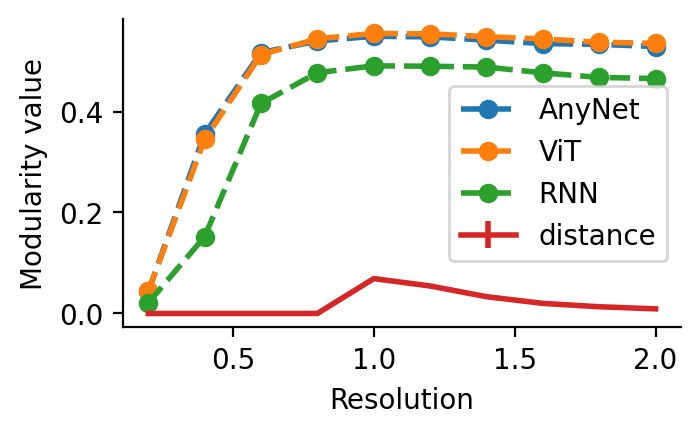

In [24]:
plt.figure(figsize=(1.8 * 2, 1 * 2), dpi=200)
for name in [ 'AnyNet', 'ViT', 'RNN']:
    plt.plot([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_value_dict[name], 'o--', linewidth=2, label=name)

plt.errorbar([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_bootstrap.mean(axis=0), yerr=modularity_bootstrap.std(axis=0), linestyle='-', linewidth=2, label='distance')
plt.ylabel('Modularity value')
plt.xlabel('Resolution')
plt.legend()
sns.despine()
plt.show()

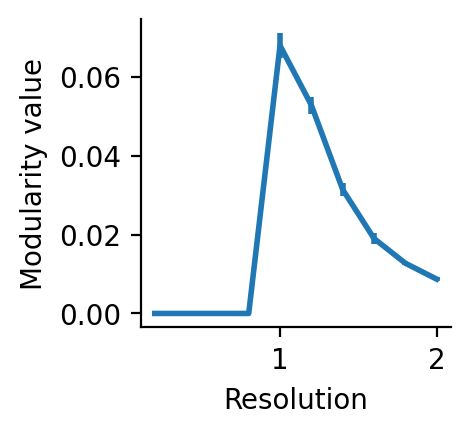

In [ ]:
plt.figure(figsize=(2, 2), dpi=200)
plt.errorbar([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_bootstrap.mean(axis=0), yerr=modularity_bootstrap.std(axis=0), linestyle='-', linewidth=2)
plt.ylabel('Modularity value')
plt.xlabel('Resolution')
# plt.ylim([0, 0.1])
sns.despine()
plt.show()

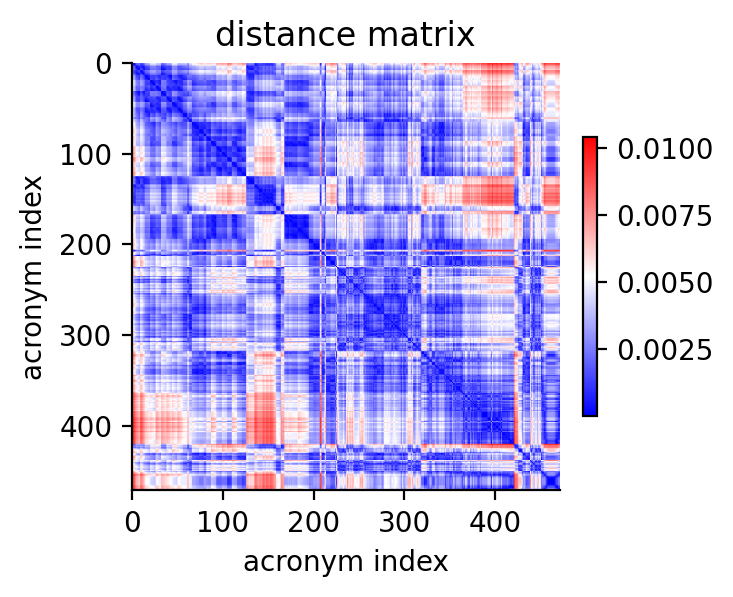

In [ ]:
plt.figure(figsize=(3, 3), dpi=200)
plt.imshow(distance_mat.detach().cpu().numpy(), cmap='bwr')
plt.xlabel('acronym index')
plt.ylabel('acronym index')
sns.despine()
plt.colorbar(fraction=0.03)
plt.title('distance matrix')
plt.show()

In [ ]:

modularity_value = []
for resolution in [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]:
    G = nx.from_numpy_array(distance_mat.detach().cpu().numpy().copy())
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    label_acronym = []
    community_label = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            label_acronym.append(acronym_list[c_index])

    community_label = np.array(community_label)
    print(f'resolution: {resolution}>>>>>>>>>>>', nx.community.modularity(G, c))
    # community_label
    modularity_value.append(nx.community.modularity(G, c))
modularity_value = np.array(modularity_value)


resolution: 0.2>>>>>>>>>>> 1.1102230246251565e-16
resolution: 0.4>>>>>>>>>>> 1.1102230246251565e-16
resolution: 0.6>>>>>>>>>>> 1.1102230246251565e-16
resolution: 0.8>>>>>>>>>>> 1.1102230246251565e-16
resolution: 1.0>>>>>>>>>>> 1.1102230246251565e-16
resolution: 1.2>>>>>>>>>>> -0.0012001161623011844
resolution: 1.4>>>>>>>>>>> -0.0012615852092467492
resolution: 1.6>>>>>>>>>>> -0.0022048394171615953
resolution: 1.8>>>>>>>>>>> -0.0022048394171615953
resolution: 2.0>>>>>>>>>>> -0.0022048394171615953


In [ ]:
plt.figure(figsize=(2, 2), dpi=200)
plt.errorbar([0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0], modularity_bootstrap.mean(axis=0), yerr=modularity_bootstrap.std(axis=0), linewidth=2)
plt.ylabel('Overlap ratio')
plt.xlabel('Resolution')
plt.ylim([0, 1.1])
plt.legend()
sns.despine()
plt.show()

In [ ]:
distance_mat = torch.zeros(len(acronym_list), len(acronym_list))
for acronym in acronym_list:
    for acronym in acronym_list:
        F.pairwise_distance(torch.tensor(index_l), torch.tensor([x, y, z])


In [ ]:
coordinates

[array([-0.005114, -0.001475, -0.003418]),
 array([-0.005114, -0.001475, -0.003543]),
 array([-0.005114, -0.001475, -0.003668]),
 array([-0.005114, -0.001475, -0.003793]),
 array([-0.005114, -0.001475, -0.003918]),
 array([-0.005114, -0.001475, -0.004043]),
 array([-0.005114, -0.0016  , -0.003168]),
 array([-0.005114, -0.0016  , -0.003293]),
 array([-0.005114, -0.0016  , -0.003418]),
 array([-0.005114, -0.0016  , -0.003543]),
 array([-0.005114, -0.0016  , -0.003668]),
 array([-0.005114, -0.0016  , -0.003793]),
 array([-0.005114, -0.0016  , -0.003918]),
 array([-0.005114, -0.0016  , -0.004043]),
 array([-0.005114, -0.0016  , -0.004168]),
 array([-0.005114, -0.001725, -0.003043]),
 array([-0.005114, -0.001725, -0.003168]),
 array([-0.005114, -0.001725, -0.003293]),
 array([-0.005114, -0.001725, -0.003418]),
 array([-0.005114, -0.001725, -0.003543]),
 array([-0.005114, -0.001725, -0.003668]),
 array([-0.005114, -0.001725, -0.003793]),
 array([-0.005114, -0.001725, -0.003918]),
 array([-0.

In [ ]:
x, y, z

(480, 0, 0)

In [ ]:
from iblatlas.plots import plot_scalar_on_slice
import matplotlib.colors as mcolors
import matplotlib as mpl

In [ ]:
br

BrainRegions(id=array([         0,        997,          8, ...,        -65,       -624,
       -304325711]), name=array(['void', 'root', 'Basic cell groups and regions', ...,
       'parafloccular sulcus (left)', 'Interpeduncular fossa (left)',
       'retina (left)'], dtype=object), acronym=array(['void', 'root', 'grey', ..., 'pfs', 'IPF', 'retina'], dtype=object), rgb=array([[  0,   0,   0],
       [255, 255, 255],
       [191, 218, 227],
       ...,
       [170, 170, 170],
       [170, 170, 170],
       [127,  46, 126]], dtype=uint8), level=array([0, 0, 1, ..., 3, 2, 1], dtype=uint16), parent=array([   nan,    nan,   997., ..., -1040., -1024.,  -997.]), order=array([   0,    0,    1, ..., 1324, 1325, 1326], dtype=uint16))

In [ ]:
def acronym_selec_gen(chan0, chan1, r=30, voxels_res=10):
    t = np.linspace(0, 1, 1000)
    x = chan0[0, 0] + t * (chan1[0, 0] - chan0[0, 0])
    y = chan0[0, 1] + t * (chan1[0, 1] - chan0[0, 1])
    z = chan0[0, 2] + t * (chan1[0, 2] - chan0[0, 2])

    xyz_l = np.c_[x, y, z]

    index_l = ba.bc.xyz2i(xyz_l)

    voxels = ba.label.shape
    voxels_selec = []
    acronym_selec = []
    for x in range(0, voxels[0], voxels_res):
        for y in range(0, voxels[1], voxels_res):
            for z in range(0, voxels[2], voxels_res):
                if torch.min(F.pairwise_distance(torch.tensor(index_l), torch.tensor([x, y, z]))) < r:
                    voxels_selec.append([x, y, z])
                    acronym_selec.append(br.id2acronym(ba.get_labels(ba.bc.i2xyz([x, y, z]), mapping='Allen'))[0])
                # pass

    acronym_selec = list(set(acronym_selec))
    acronym_selec_index = np.unique(np.array([acronym_Allen_Beryl_list.index(acronym) for acronym in acronym_selec if acronym in acronym_Allen_Beryl_list]))
    acronym_selec_act = torch.zeros(len(acronym_Allen_Beryl_list))
    acronym_selec_act[acronym_selec_index] = 1

    return acronym_selec, acronym_selec_index, acronym_selec_act